# Combine two training sets for lists 

- creative writing + Ultrachat
- for all policies (on_policy, incentivised, prompted, off policy)
- test on shakespeare 

run ```bash python scripts/get_probe_hyperparams_and_results_combined.py```

Found 4 result files

COMBINED PROBE RESULTS

Train: writingprompts_incentivised+ultrachat_incentivised
Test:  shakespeare + on_policy
  ROC AUC:      0.8590
  Accuracy:     0.5660
  TPR@1%FPR:    0.3300

Train: writingprompts_off_policy+ultrachat_off_policy
Test:  shakespeare + on_policy
  ROC AUC:      0.8443
  Accuracy:     0.5290
  TPR@1%FPR:    0.3040

Train: writingprompts_on_policy+ultrachat_on_policy
Test:  shakespeare + on_policy
  ROC AUC:      0.8526
  Accuracy:     0.5410
  TPR@1%FPR:    0.2840

Train: writingprompts_prompted+ultrachat_prompted
Test:  shakespeare + on_policy
  ROC AUC:      0.8210
  Accuracy:     0.5920
  TPR@1%FPR:    0.2420


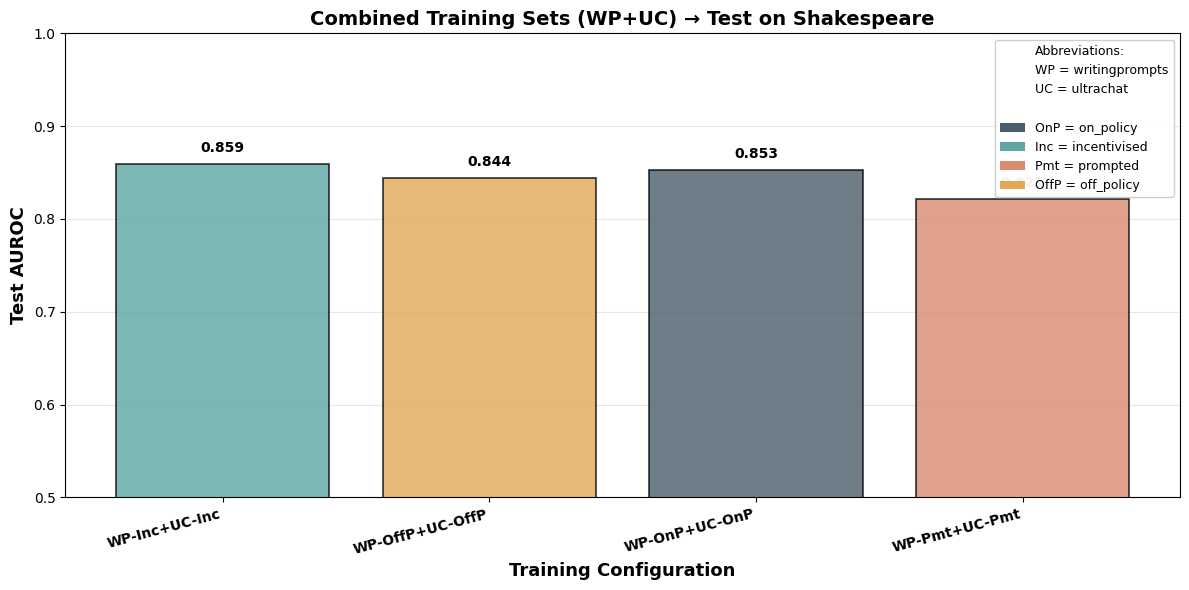


✓ Plot saved to ../combined_probe_results/combined_probes_auroc.png


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Patch

# Load and plot results
results_dir = Path("../combined_probe_results")
json_files = list(results_dir.glob("*.json"))

print(f"Found {len(json_files)} result files\n")

# Print summary
print("="*80)
print("COMBINED PROBE RESULTS")
print("="*80)

for json_file in sorted(json_files):
    with open(json_file, 'r') as f:
        data = json.load(f)
    
    train_name = data['train_set']['combined_name']
    test_name = f"{data['test_set']['datasource']} + {data['test_set']['generation_method']}"
    results = data['results']
    
    print(f"\nTrain: {train_name}")
    print(f"Test:  {test_name}")
    print(f"  ROC AUC:      {results['roc_auc']:.4f}")
    print(f"  Accuracy:     {results['accuracy']:.4f}")
    print(f"  TPR@1%FPR:    {results['tpr_at_1_fpr']:.4f}")

# Create bar chart
train_configs = []
auroc_values = []

for json_file in sorted(json_files):
    with open(json_file, 'r') as f:
        data = json.load(f)
    
    # Create abbreviated label
    train_name = data['train_set']['combined_name']
    label = train_name.replace('writingprompts', 'WP').replace('ultrachat', 'UC')
    label = label.replace('on_policy', 'OnP').replace('off_policy', 'OffP')
    label = label.replace('incentivised', 'Inc').replace('prompted', 'Pmt')
    label = label.replace('_', '-')
    
    train_configs.append(label)
    auroc_values.append(data['results']['roc_auc'])

# Colors by generation method
colors = []
for config in train_configs:
    if 'OnP' in config:
        colors.append('#4a5d6b')
    elif 'Inc' in config:
        colors.append('#5da5a3')
    elif 'Pmt' in config:
        colors.append('#d98a6f')
    elif 'OffP' in config:
        colors.append('#e0a855')
    else:
        colors.append('#7f8c8d')

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(train_configs))
bars = ax.bar(x, auroc_values, color=colors, edgecolor='black', linewidth=1.2, alpha=0.8)

ax.set_xlabel('Training Configuration', fontsize=13, fontweight='bold')
ax.set_ylabel('Test AUROC', fontsize=13, fontweight='bold')
ax.set_title('Combined Training Sets (WP+UC) → Test on Shakespeare', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(train_configs, rotation=15, ha='right', fontweight='bold')
ax.set_ylim([0.5, 1.0])
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, auroc_values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Add legend explaining abbreviations
legend_elements = [
    Patch(facecolor='none', edgecolor='none', label='Abbreviations:'),
    Patch(facecolor='none', edgecolor='none', label='WP = writingprompts'),
    Patch(facecolor='none', edgecolor='none', label='UC = ultrachat'),
    Patch(facecolor='none', edgecolor='none', label=''),
    Patch(facecolor='#4a5d6b', label='OnP = on_policy'),
    Patch(facecolor='#5da5a3', label='Inc = incentivised'),
    Patch(facecolor='#d98a6f', label='Pmt = prompted'),
    Patch(facecolor='#e0a855', label='OffP = off_policy'),
]
ax.legend(handles=legend_elements, loc='upper right', framealpha=0.95, fontsize=9)

plt.tight_layout()
plt.savefig(results_dir / 'combined_probes_auroc.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Plot saved to {results_dir / 'combined_probes_auroc.png'}")


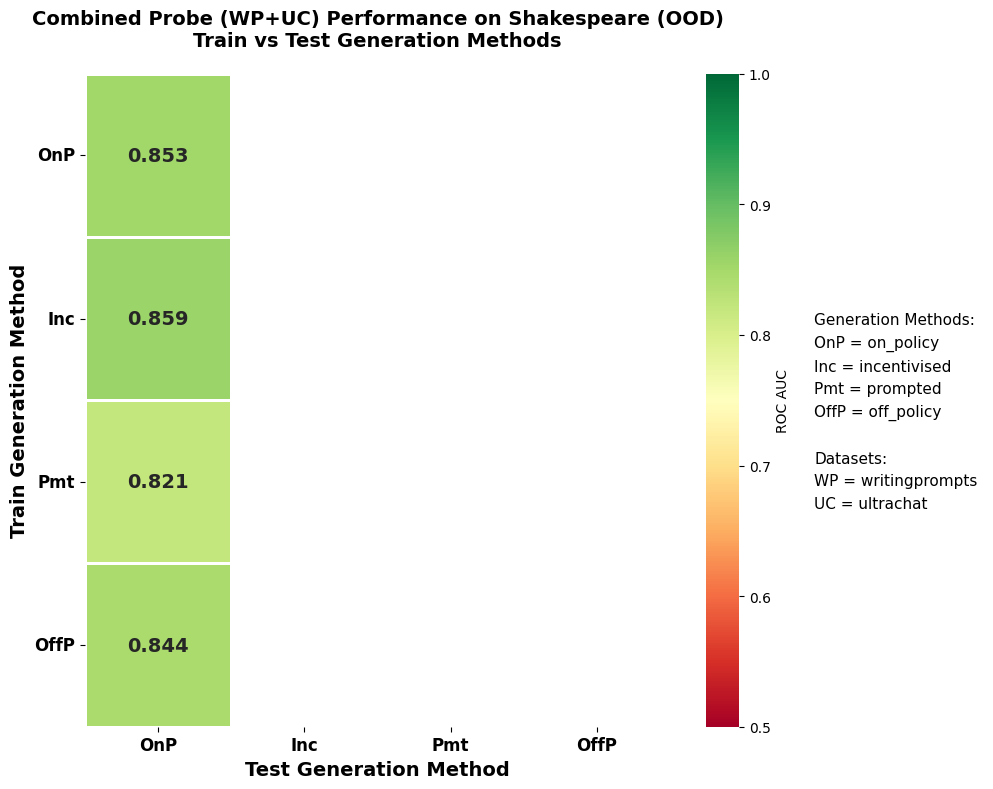


✓ Cross-testing heatmap saved to ../combined_probe_results/combined_probes_cross_testing_heatmap.png

Data availability:
  Train: on_policy       → Test: on_policy       = 0.853
  Train: on_policy       → Test: incentivised    = (no data)
  Train: on_policy       → Test: prompted        = (no data)
  Train: on_policy       → Test: off_policy      = (no data)
  Train: incentivised    → Test: on_policy       = 0.859
  Train: incentivised    → Test: incentivised    = (no data)
  Train: incentivised    → Test: prompted        = (no data)
  Train: incentivised    → Test: off_policy      = (no data)
  Train: prompted        → Test: on_policy       = 0.821
  Train: prompted        → Test: incentivised    = (no data)
  Train: prompted        → Test: prompted        = (no data)
  Train: prompted        → Test: off_policy      = (no data)
  Train: off_policy      → Test: on_policy       = 0.844
  Train: off_policy      → Test: incentivised    = (no data)
  Train: off_policy      → Test: prompte

In [5]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.patches import Patch

# Load results
results_dir = Path("../combined_probe_results")
json_files = list(results_dir.glob("*.json"))

# Define generation methods
generation_methods = ['on_policy', 'incentivised', 'prompted', 'off_policy']
gen_method_abbrev = {
    'on_policy': 'OnP',
    'incentivised': 'Inc', 
    'prompted': 'Pmt',
    'off_policy': 'OffP'
}

# Create matrix: rows = train gen method, columns = test gen method
# Initialize with NaN
results_matrix = np.full((len(generation_methods), len(generation_methods)), np.nan)

# Fill in the matrix
for json_file in json_files:
    with open(json_file, 'r') as f:
        data = json.load(f)
    
    # Extract train generation method from combined name
    train_name = data['train_set']['combined_name']
    # Parse: "writingprompts_on_policy+ultrachat_on_policy"
    # Find which generation method is in the name
    train_gen_method = None
    for gm in generation_methods:
        if gm in train_name:
            train_gen_method = gm
            break
    
    if train_gen_method is None:
        print(f"Warning: Could not parse generation method from: {train_name}")
        continue
    
    # Extract test generation method
    test_gen_method = data['test_set']['generation_method']
    
    # Get AUROC
    auroc = data['results']['roc_auc']
    
    # Find indices
    train_idx = generation_methods.index(train_gen_method)
    test_idx = generation_methods.index(test_gen_method)
    
    results_matrix[train_idx, test_idx] = auroc

# Create heatmap
fig, ax = plt.subplots(figsize=(10, 8))

# Create annotations with proper formatting
annot_matrix = np.empty_like(results_matrix, dtype=object)
for i in range(results_matrix.shape[0]):
    for j in range(results_matrix.shape[1]):
        if np.isnan(results_matrix[i, j]):
            annot_matrix[i, j] = ""
        else:
            annot_matrix[i, j] = f"{results_matrix[i, j]:.3f}"

# Create heatmap
sns.heatmap(
    results_matrix,
    annot=annot_matrix,
    fmt='',
    cmap='RdYlGn',
    vmin=0.5,
    vmax=1.0,
    cbar_kws={'label': 'ROC AUC'},
    linewidths=2,
    linecolor='white',
    ax=ax,
    annot_kws={"size": 14, "weight": "bold"}
)

# Labels
train_labels = [gen_method_abbrev[gm] for gm in generation_methods]
test_labels = [gen_method_abbrev[gm] for gm in generation_methods]

ax.set_xticklabels(test_labels, fontweight='bold', fontsize=12)
ax.set_yticklabels(train_labels, fontweight='bold', fontsize=12, rotation=0)
ax.set_xlabel("Test Generation Method", fontsize=14, fontweight='bold')
ax.set_ylabel("Train Generation Method", fontsize=14, fontweight='bold')
ax.set_title("Combined Probe (WP+UC) Performance on Shakespeare (OOD)\nTrain vs Test Generation Methods", 
             fontsize=14, fontweight='bold', pad=20)

# Add legend for abbreviations
legend_elements = [
    Patch(facecolor='none', edgecolor='none', label=''),
    Patch(facecolor='none', edgecolor='none', label='Generation Methods:'),
    Patch(facecolor='none', edgecolor='none', label='OnP = on_policy'),
    Patch(facecolor='none', edgecolor='none', label='Inc = incentivised'),
    Patch(facecolor='none', edgecolor='none', label='Pmt = prompted'),
    Patch(facecolor='none', edgecolor='none', label='OffP = off_policy'),
    Patch(facecolor='none', edgecolor='none', label=''),
    Patch(facecolor='none', edgecolor='none', label='Datasets:'),
    Patch(facecolor='none', edgecolor='none', label='WP = writingprompts'),
    Patch(facecolor='none', edgecolor='none', label='UC = ultrachat'),
]

ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.15, 0.5), 
          frameon=False, fontsize=11)

plt.tight_layout()
plt.savefig(results_dir / 'combined_probes_cross_testing_heatmap.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Cross-testing heatmap saved to {results_dir / 'combined_probes_cross_testing_heatmap.png'}")

# Show which cells have data
print("\nData availability:")
for i, train_gm in enumerate(generation_methods):
    for j, test_gm in enumerate(generation_methods):
        if not np.isnan(results_matrix[i, j]):
            print(f"  Train: {train_gm:15s} → Test: {test_gm:15s} = {results_matrix[i, j]:.3f}")
        else:
            print(f"  Train: {train_gm:15s} → Test: {test_gm:15s} = (no data)")
